# mlAgent Run Comparison

Compare selected runs across different strategies/architectures. Understand score progression, cost efficiency, and the experiment process.

In [21]:
# ====== CONFIG: edit these to select runs ======

# Option 1: Specify run folder paths directly (takes priority if non-empty)
RUN_PATHS = [
    "workspace/run_20260326_142157_board_random-acts-of-pizza",
    "workspace/run_20260326_142156_random-acts-of-pizza",
]
# RUN_PATHS = [
#     "workspace/run_20260326_173018_spooky-author-identification",
#     "workspace/run_20260326_173018_board_spooky-author-identification",
# ]

# Option 2: Auto-discover runs from workspace, with optional filters
WORKSPACE = "workspace"        # root folder containing packs
FILTER_COMPETITION = ""        # e.g. "spooky-author-identification" (empty = all)
FILTER_TIME_AFTER = ""         # e.g. "20260324_150000" (empty = all)
FILTER_TIME_BEFORE = ""        # e.g. "20260324_180000" (empty = all)
FILTER_STRATEGY = ""           # e.g. "board" or "todo" or "" for all

# Display
LOWER_IS_BETTER = False         # set False if your metric is accuracy-like

In [22]:
import json, re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

# ---- Discover runs ----
def parse_run_dir(name):
    """Extract timestamp and competition from run folder name like run_20260324_152740_board_spooky-author-identification"""
    m = re.match(r"run_(\d{8}_\d{6})_(?:(board|todo)_)?(.*)", name)
    if not m:
        return None
    return {"time": m.group(1), "strategy_tag": m.group(2) or "baseline", "competition": m.group(3)}

def discover_runs(workspace):
    found = []
    ws = Path(workspace)
    for pack_dir in sorted(ws.iterdir()):
        if not pack_dir.is_dir() or pack_dir.name.endswith(".tgz"):
            continue
        for run_dir in sorted(pack_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if (run_dir / "experiment_log.json").exists():
                found.append(run_dir)
    return found

def load_run(run_path):
    run_path = Path(run_path)
    info = parse_run_dir(run_path.name) or {"time": "?", "strategy_tag": "?", "competition": "?"}
    with open(run_path / "experiment_log.json") as f:
        log = json.load(f)
    run = {"path": run_path, "log": log, **info}
    for extra in ["experiment_board.json", "experiment_map.json", "todo_list.json"]:
        p = run_path / extra
        if p.exists():
            with open(p) as f:
                run[extra.replace(".json", "")] = json.load(f)
    return run

# ---- Build run list ----
if RUN_PATHS:
    run_dirs = [Path(p) for p in RUN_PATHS]
else:
    run_dirs = discover_runs(WORKSPACE)

runs = []
for rd in run_dirs:
    r = load_run(rd)
    # Apply filters
    if FILTER_COMPETITION and FILTER_COMPETITION not in r["competition"]:
        continue
    if FILTER_TIME_AFTER and r["time"] < FILTER_TIME_AFTER:
        continue
    if FILTER_TIME_BEFORE and r["time"] > FILTER_TIME_BEFORE:
        continue
    if FILTER_STRATEGY and FILTER_STRATEGY not in r["strategy_tag"]:
        continue
    runs.append(r)

# Generate short labels
for r in runs:
    r["label"] = f"{r['strategy_tag']}_{r['time']}"

palette = sns.color_palette("tab10", max(len(runs), 1))
for i, r in enumerate(runs):
    r["color"] = palette[i]

cum_fn = np.minimum.accumulate if LOWER_IS_BETTER else np.maximum.accumulate

def get_scores(run):
    """Return scores as float array, using nan for missing/None values."""
    return np.array([
        rd["grade"]["score"] if rd["grade"].get("score") is not None else np.nan
        for rd in run["log"]
    ], dtype=float)

print(f"Loaded {len(runs)} runs:")
for r in runs:
    scores = get_scores(r)
    valid = scores[~np.isnan(scores)]
    best = (np.nanmin(scores) if LOWER_IS_BETTER else np.nanmax(scores)) if len(valid) > 0 else float("nan")
    print(f"  [{r['label']}] {r['competition']}  |  {len(r['log'])} rounds  |  best={best:.5f}  |  {r['path']}")

Loaded 2 runs:
  [board_20260326_142157] random-acts-of-pizza  |  28 rounds  |  best=0.67472  |  workspace/run_20260326_142157_board_random-acts-of-pizza
  [baseline_20260326_142156] random-acts-of-pizza  |  40 rounds  |  best=0.69496  |  workspace/run_20260326_142156_random-acts-of-pizza


## 1. Score Progression

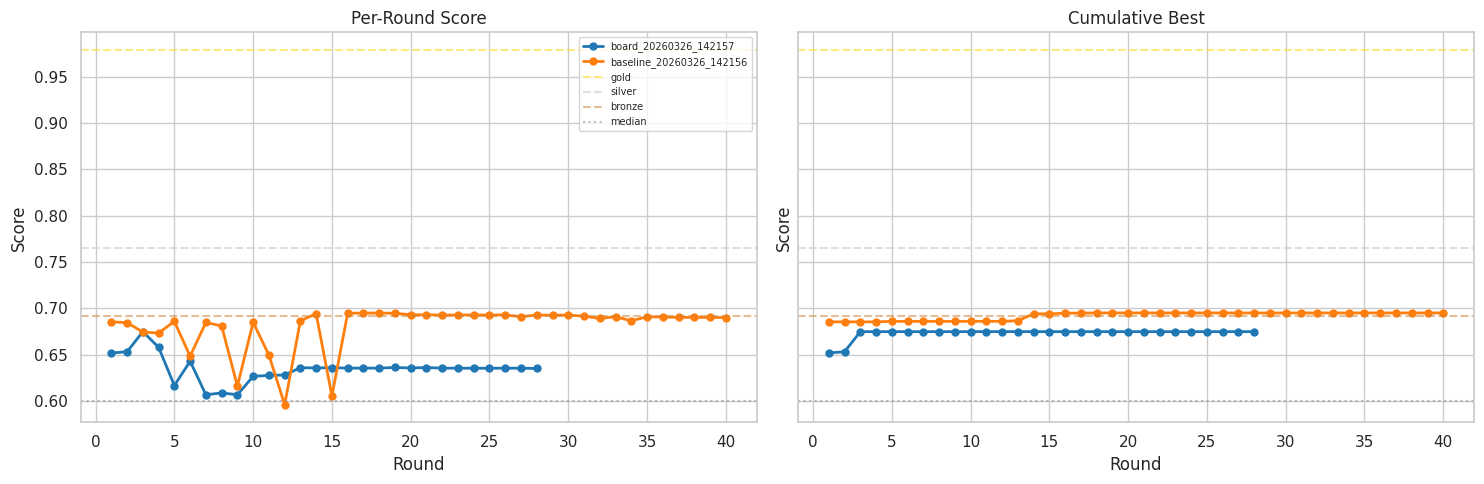

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for r in runs:
    scores = get_scores(r)
    rounds = np.array([rd["round"] for rd in r["log"]])
    # cum_fn doesn't handle nan; use nanmin/nanmax accumulate workaround
    cum_best = np.array([
        (np.nanmin(scores[:i+1]) if LOWER_IS_BETTER else np.nanmax(scores[:i+1]))
        for i in range(len(scores))
    ])
    axes[0].plot(rounds, scores, marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)
    axes[1].plot(rounds, cum_best, marker="o", label=r["label"], color=r["color"], linewidth=2, markersize=5)

# Medal thresholds
sample_grade = runs[0]["log"][0]["grade"]
for ax in axes:
    for key, color, ls in [("gold_threshold", "gold", "--"), ("silver_threshold", "silver", "--"),
                            ("bronze_threshold", "#cd7f32", "--"), ("median_threshold", "gray", ":")]:
        if key in sample_grade:
            ax.axhline(y=sample_grade[key], color=color, linestyle=ls, alpha=0.5,
                       label=key.replace("_threshold", "") if ax is axes[0] else None)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()

axes[0].set_title("Per-Round Score")
axes[1].set_title("Cumulative Best")
for ax in axes:
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

## 2. Per-Round Improvement

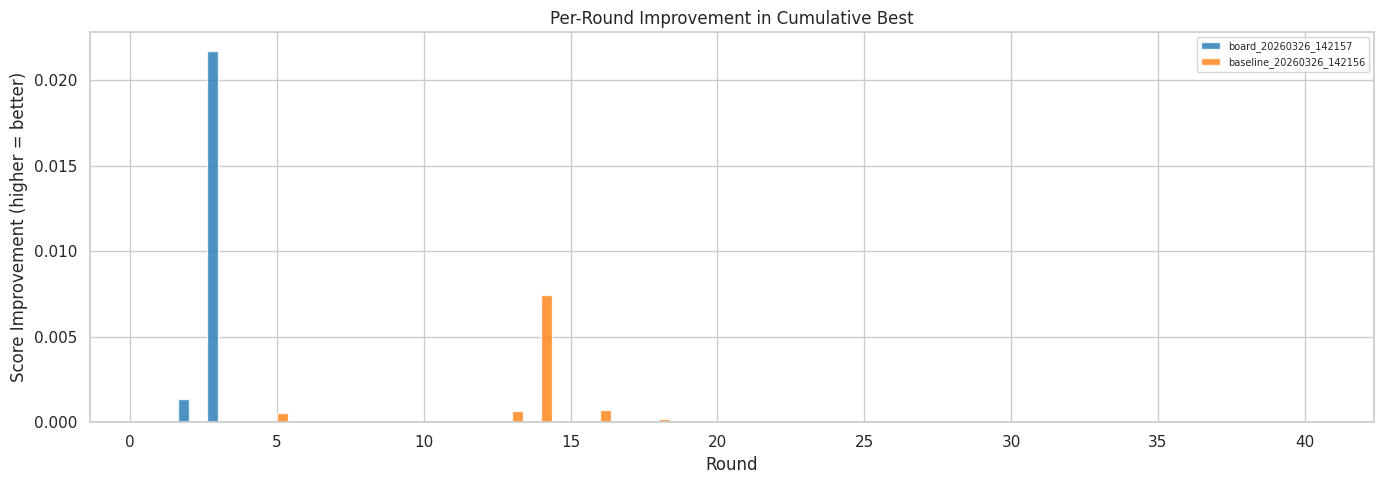

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
n = len(runs)
bar_w = 0.75 / n

for i, r in enumerate(runs):
    scores = get_scores(r)
    cum_best = np.array([
        (np.nanmin(scores[:j+1]) if LOWER_IS_BETTER else np.nanmax(scores[:j+1]))
        for j in range(len(scores))
    ])
    deltas = np.concatenate([[0.0], np.diff(cum_best)])
    improvement = -deltas if LOWER_IS_BETTER else deltas
    rounds = np.array([rd["round"] for rd in r["log"]])
    offset = (i - n/2 + 0.5) * bar_w
    ax.bar(rounds + offset, improvement, width=bar_w, label=r["label"], color=r["color"], alpha=0.8)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Round")
ax.set_ylabel("Score Improvement (higher = better)")
ax.set_title("Per-Round Improvement in Cumulative Best")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Cost & Token Efficiency

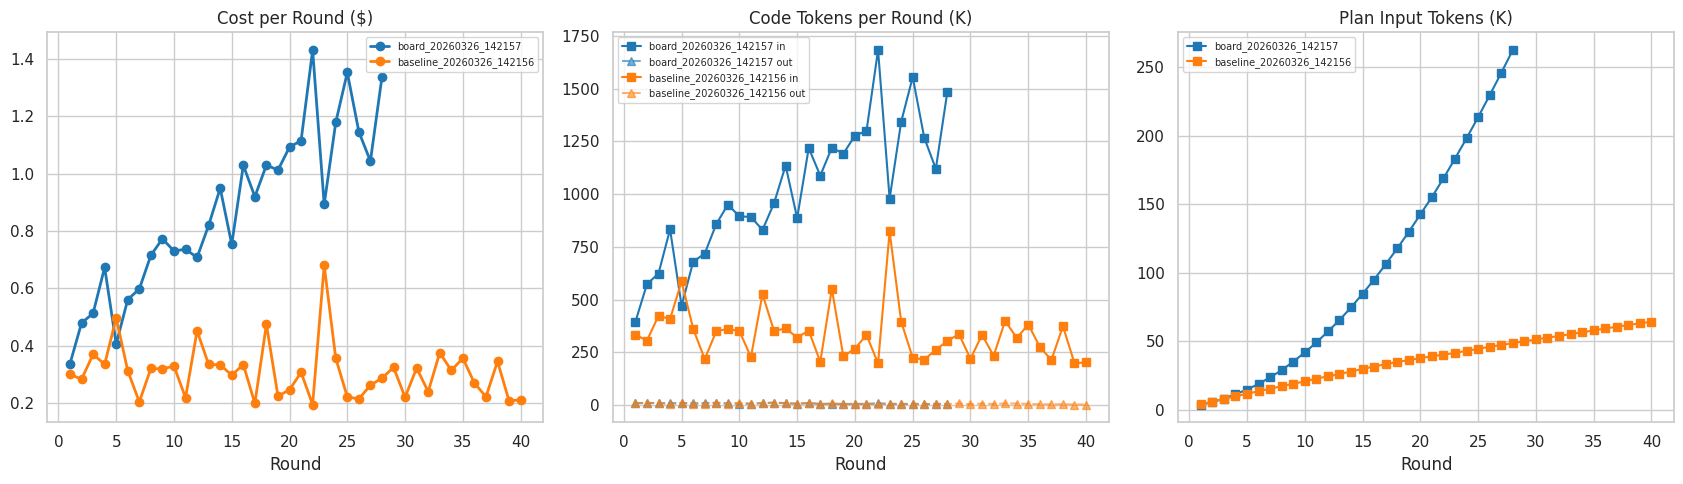

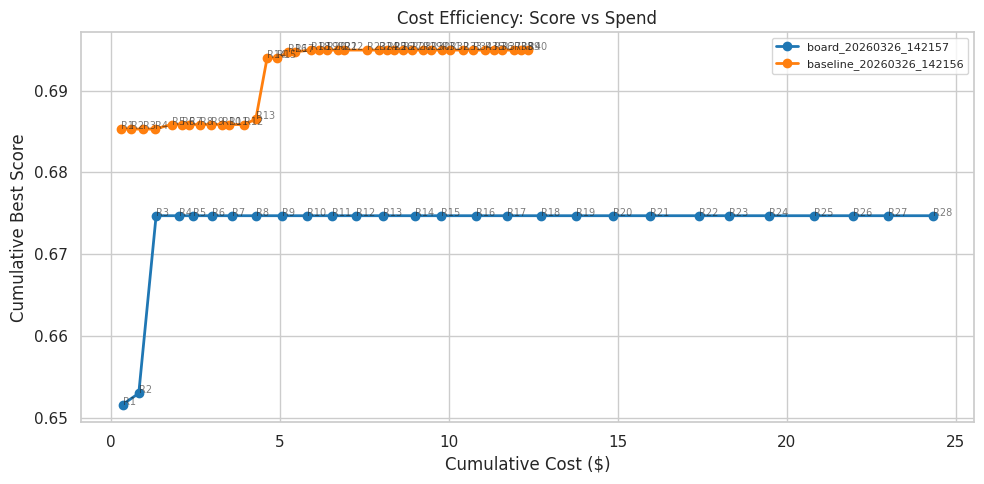


Total cost per run:
  board_20260326_142157: $24.33
  baseline_20260326_142156: $12.33


In [25]:
has_cost = [r for r in runs if "estimated_cost_usd" in r["log"][0]]

if has_cost:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for r in has_cost:
        rounds = [rd["round"] for rd in r["log"]]
        costs = [rd["estimated_cost_usd"] for rd in r["log"]]
        code_in = [rd["code_tokens"]["input"] / 1000 for rd in r["log"]]
        code_out = [rd["code_tokens"]["output"] / 1000 for rd in r["log"]]
        plan_in = [rd["plan_tokens"]["input"] / 1000 for rd in r["log"]]

        axes[0].plot(rounds, costs, marker="o", label=r["label"], color=r["color"], linewidth=2)
        axes[1].plot(rounds, code_in, marker="s", label=r["label"] + " in", color=r["color"])
        axes[1].plot(rounds, code_out, marker="^", linestyle="--", color=r["color"], alpha=0.6, label=r["label"] + " out")
        axes[2].plot(rounds, plan_in, marker="s", label=r["label"], color=r["color"])

    axes[0].set_title("Cost per Round ($)")
    axes[1].set_title("Code Tokens per Round (K)")
    axes[2].set_title("Plan Input Tokens (K)")
    for ax in axes:
        ax.set_xlabel("Round")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # Cumulative cost vs score improvement
    fig, ax = plt.subplots(figsize=(10, 5))
    for r in has_cost:
        scores = np.array([rd["grade"]["score"] for rd in r["log"]])
        cum_best = cum_fn(scores)
        cum_cost = np.cumsum([rd["estimated_cost_usd"] for rd in r["log"]])
        ax.plot(cum_cost, cum_best, marker="o", label=r["label"], color=r["color"], linewidth=2)
        # Annotate rounds
        for j, rd in enumerate(r["log"]):
            ax.annotate(f"R{rd['round']}", (cum_cost[j], cum_best[j]), fontsize=7, alpha=0.6)
    ax.set_xlabel("Cumulative Cost ($)")
    ax.set_ylabel("Cumulative Best Score")
    ax.set_title("Cost Efficiency: Score vs Spend")
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTotal cost per run:")
    for r in has_cost:
        total = sum(rd["estimated_cost_usd"] for rd in r["log"])
        print(f"  {r['label']}: ${total:.2f}")
else:
    print("No runs have cost data.")

## 4. Experiment Board / Map: Branch Exploration

[{'path': PosixPath('workspace/run_20260326_142157_board_random-acts-of-pizza'), 'log': [{'round': 1, 'plan': 'This is a small-tabular + text competition with AUC evaluation, so the best early strategy is to cover a few strong, diverse directions and save OOFs for later stacking.\n\nKey task read:\n- Target is binary success/failure, metric is ROC AUC.\n- Data is small enough for careful cross-validation; leakage risk exists in retrieval-time fields.\n- Text should matter a lot, but structured metadata likely gives strong signal too.\n- Test set lacks some retrieval-only fields, so train/test feature consistency matters.\n- Good long-run path: strong linear text baseline, metadata model, and later stacking.\n\n[BOARD:Text Linear Baseline] TF-IDF on request_title + request_text_edit_aware with logistic regression / linear SVM-style probabilities, strong first text benchmark\n\n[BOARD:Metadata Model] structured features only with missingness handling, date/time, activity/history stats, a

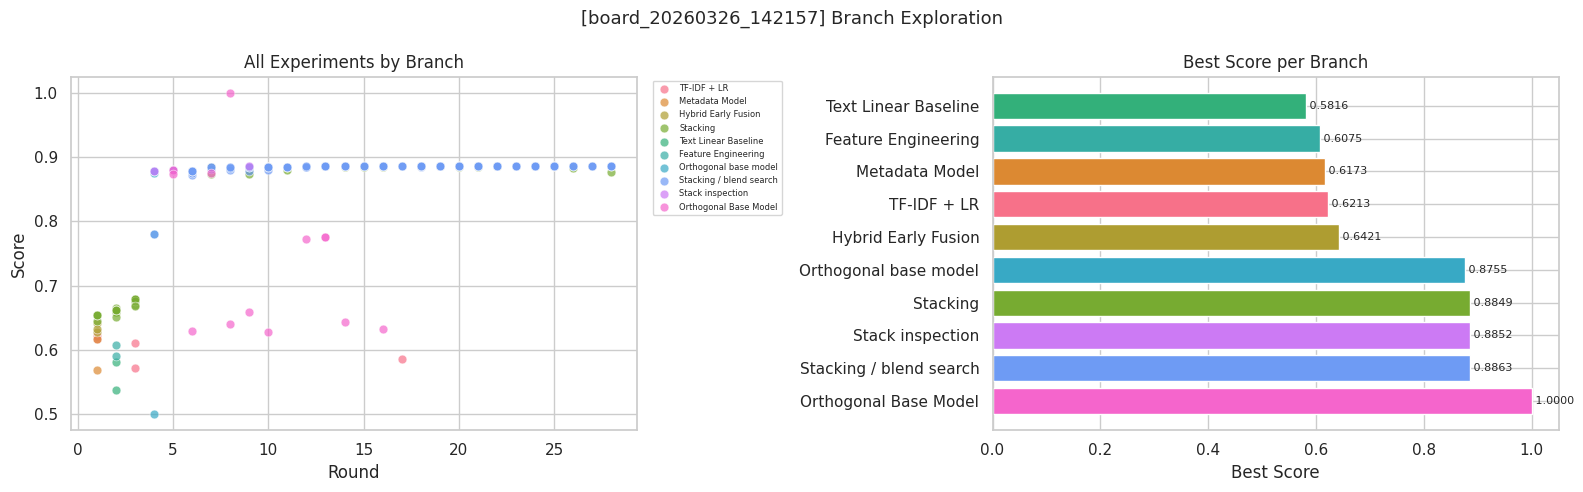

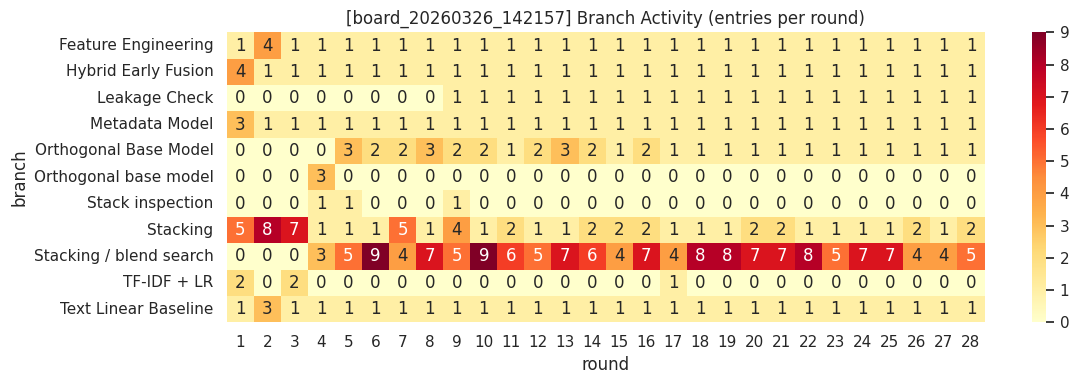

In [26]:
board_runs = [r for r in runs if "experiment_board" in r or "experiment_map" in r]
print(board_runs)
for r in board_runs:
    board = r.get("experiment_board") or r.get("experiment_map", [])
    if not board:
        continue

    df = pd.DataFrame(board)
    print(df)
    scored = df[df["score"].notna()].copy()
    if scored.empty:
        print(f"{r['label']}: no scored experiments in board")
        continue

    branches = scored["branch"].unique()
    bp = sns.color_palette("husl", len(branches))
    bcmap = dict(zip(branches, bp))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"[{r['label']}] Branch Exploration", fontsize=13)

    # Left: experiments over rounds, colored by branch
    ax = axes[0]
    for b in branches:
        sub = scored[scored["branch"] == b]
        ax.scatter(sub["round"], sub["score"], color=bcmap[b], label=b, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)
    if LOWER_IS_BETTER:
        ax.invert_yaxis()
    ax.set_xlabel("Round")
    ax.set_ylabel("Score")
    ax.set_title("All Experiments by Branch")
    ax.legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

    # Right: best per branch
    ax = axes[1]
    agg_fn = "min" if LOWER_IS_BETTER else "max"
    best = scored.groupby("branch")["score"].agg(agg_fn).sort_values(ascending=LOWER_IS_BETTER)
    colors = [bcmap[b] for b in best.index]
    bars = ax.barh(best.index, best.values, color=colors)
    for bar, score in zip(bars, best.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {score:.4f}", va="center", fontsize=8)
    ax.set_xlabel("Best Score")
    ax.set_title("Best Score per Branch")
    if LOWER_IS_BETTER:
        ax.invert_xaxis()

    plt.tight_layout()
    plt.show()

    # Activity heatmap
    activity = df.groupby(["round", "branch"]).size().reset_index(name="count")
    pivot = activity.pivot(index="branch", columns="round", values="count").fillna(0)
    fig, ax = plt.subplots(figsize=(12, max(3, 0.4 * len(branches))))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"[{r['label']}] Branch Activity (entries per round)")
    plt.tight_layout()
    plt.show()

## 5. Knowledge Base Growth

In [27]:
has_kb = False
fig, ax = plt.subplots(figsize=(10, 5))
for r in runs:
    sizes = []
    for rd in r["log"]:
        s = rd.get("board_size") or rd.get("map_entries")
        if s is not None:
            sizes.append((rd["round"], s))
    if sizes:
        has_kb = True
        rs, ss = zip(*sizes)
        ax.plot(rs, ss, marker="o", label=r["label"], color=r["color"], linewidth=2)

if has_kb:
    ax.set_xlabel("Round")
    ax.set_ylabel("Board / Map Entries")
    ax.set_title("Knowledge Base Growth Over Rounds")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("No runs have board/map size data.")

No runs have board/map size data.


## 6. Round-by-Round Process Log

Expand each run's per-round plan and result summary.

In [28]:
from IPython.display import display, HTML

def truncate(text, max_chars=600):
    if not text:
        return ""
    text = text.strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars] + "..."

for r in runs:
    rows = []
    for rd in r["log"]:
        g = rd["grade"]
        score_val = g.get("score")
        medal = "gold" if g.get("gold_medal") else "silver" if g.get("silver_medal") else \
                "bronze" if g.get("bronze_medal") else "above_median" if g.get("above_median") else "-"
        rows.append({
            "Round": rd["round"],
            "Score": f"{score_val:.5f}" if score_val is not None else "N/A",
            "Valid": g.get("valid_submission", True),
            "Medal": medal,
            "Plan (truncated)": truncate(rd.get("plan", ""), 300),
            "Result Summary (truncated)": truncate(rd.get("coding_summary", ""), 400),
        })
    df_log = pd.DataFrame(rows)
    print(f"\n{'='*80}")
    print(f"  {r['label']}  |  {r['competition']}")
    print(f"{'='*80}")
    display(df_log.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).set_table_styles(
        [{"selector": "th", "props": [("text-align", "left")]}]
    ))


  board_20260326_142157  |  random-acts-of-pizza


,Round,Score,Valid,Medal,Plan (truncated),Result Summary (truncated)
0,1,0.65165,True,above_median,"This is a small-tabular + text competition with AUC evaluation, so the best early strategy is to cover a few strong, diverse directions and save OOFs for later stacking. Key task read: - Target is binary success/failure, metric is ROC AUC. - Data is small enough for careful cross-validation; leakag...","=== After round 1 (1 agent(s)) === --- Agent 0 --- Summary of this round: What was tried - Loaded and inspected train/test, checked label balance and missingness. - Built a text-only TF-IDF + logistic regression baseline. - Built a metadata-only logistic regression baseline. - Created a simple weighted blend of text and metadata. - Added handcrafted features: - text length, word count, punctua..."
1,2,0.65302,True,above_median,"The board shows a strong progression: the hybrid feature-rich linear model is better than pure text, and stacking is already the best direction. Metadata alone is weak, but it contributes useful diversity in the stack. The main remaining upside is likely from stronger text variants, richer engineere...","=== After round 2 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Built a new diverse text baseline: - word+char TF-IDF with `SGDClassifier(log_loss)` - body-only word+char TF-IDF with elastic-net SGD - Expanded engineered features: - readability-ish / token diversity proxies - punctuation counts, pronouns, URLs, digits - title/body interaction features - subred..."
2,3,0.67472,True,above_median,"The board is now clear: stacking is winning, and the best gains came from adding diverse but not redundant sources. The weak body-only baseline and modest feature-only models are still useful as diversity, but they’re not worth standalone focus. The next likely gains are from a stronger meta-learner...",=== After round 3 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded and verified the RAOP data. - Kept a valid submission early using prior stack artifacts. - Built new text sources for diversity: - title-only + body-only TF-IDF with distinct preprocessing - mixed title/body word+char SGD model - Trained a nonlinear meta-learner: - HistGradientBoostingClassifier ...
3,4,0.65778,True,above_median,"The board now strongly suggests diminishing returns from more similar linear text variants. The full-stack blend is best, and the nonlinear HGB stack is useful mainly as a complementary source. The next likely gain is from one truly orthogonal base model family or a more systematic blend over the to...","=== After round 4 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded and inspected the train/test data; confirmed train size 2878, test size 1162, positive rate ~0.248. - Built a new orthogonal base model family: - `CountVectorizer(1,2)` + selected numeric metadata + `ExtraTreesClassifier` - `CountVectorizer` + `TruncatedSVD(50)` + numeric metadata + `HistGradientBo..."
4,5,0.61648,True,above_median,"This round changed the shape of the search. The new orthogonal count/SVD/tree models are by far the most interesting additions, and the `hgb_svd` source is now the strongest single model on the board. The old linear TF-IDF family is mostly saturated, but it still contributes as stack diversity. The ...",=== After round 5 (1 agent(s)) === --- Agent 0 --- Summary of the round: What was tried - Loaded and inspected the train/test data and confirmed the target rate. - Used the previously saved OOF/test artifacts from many base models. - Ran multiple blend searches centered on: - `hgb_svd` - `et_counts` - `stack_logistic_all` - `blend_top3` - `meta_hgb` - Tried: - convex 3-way blends -...
5,6,0.64277,True,above_median,"The board now has a clear dominant theme: `hgb_svd` plus a small set of complementary sources is the best validated path, and the search space is getting more about blend refinement than model family discovery. That said, the current “orthogon


  baseline_20260326_142156  |  random-acts-of-pizza


,Round,Score,Valid,Medal,Plan (truncated),Result Summary (truncated)
0,1,0.68531,True,above_median,"Agent 0: ## Overall Strategy This is a small-to-medium tabular + text competition with a probability metric (AUC), so the winning path is usually: strong text featurization + simple tabular features + diverse linear/tree models + stacking. ### Phase 1: Establish diverse baselines (Rounds 1–5) Goal:...","=== After round 1 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded and inspected the train/test data, checked label balance. - Built multiple text baselines: - Word TF-IDF + logistic regression - Character TF-IDF + logistic regression - Built tabular baselines: - Logistic regression on numeric/meta features - ExtraTrees on engineered numeric/meta features - Bu..."
1,2,0.68445,True,above_median,"Agent 0: ## Overall Strategy The first round already found a very strong direction: **stacking base models beats any single model**, and the best single base is **text + tabular linear**. So the strategy should shift from broad baseline exploration to **stack expansion + stronger meta-learning + bet...",=== After round 2 (1 agent(s)) === --- Agent 0 --- Summary of the round: What I tried - Loaded the train/test JSON data and inspected the fields. - Built a strong baseline with: - concatenated title + edit-aware body text - TF-IDF word features - engineered numeric/text-stat features - logistic regression - Added several diverse base models and saved OOF/test predictions: - title-only ...
2,3,0.67425,True,above_median,"Agent 0: ## Overall Strategy The results confirm the key path: **diverse OOF sources + stacking** is the right meta-strategy, while chasing single-model strength is secondary. The new stack improved but didn’t beat the global best submission, so the next step is to make the stack **more expressive**...",=== After round 3 (1 agent(s)) === --- Agent 0 --- Summary of the round: What was tried - Loaded the Kaggle pizza data and inspected class balance. - Reused prior OOF artifacts and built a stacking baseline with logistic regression. - Added a new style/readability feature model using simple text-derived features. - Added a richer tabular/subreddit feature model. - Added a dense text model via TF...
3,4,0.67317,True,above_median,"Agent 0: ## Overall Strategy The round 3 result is a red flag: the reported **0.83958 OOF blend** is far too high relative to the actual submission score history, which strongly suggests **an optimistic blend / leakage / evaluation mismatch** in the stacking workflow. So the strategy should now shif...",=== After round 4 (1 agent(s)) === --- Agent 0 --- Here’s a concise summary of the round. ### What was tried - Loaded and inspected the competition data. - Discovered the provided `train.csv` / `test.csv` were not the usable datasets in this environment; the real data was in `train.json` / `test.json`. - Parsed the JSON files manually with `json.load(...)`. - Audited all available saved OOF arti...
4,5,0.68586,True,above_median,"Agent 0: ## Overall Strategy The clean-audit round was useful: it confirmed the earlier high scores were contaminated by leakage/misaligned blending, and it established a trustworthy stack baseline at **0.68107**. Since the global best submission is still **0.68531**, the path forward is to **increm...","=== After round 5 (1 agent(s)) === --- Agent 0 --- Here’s a concise recap. ### What was tried - Loaded the competition data from the converted CSVs in `input/converted_csvs/`. - Inspected many existing OOF artifacts from prior rounds. - Built and evaluated a stacking model over the saved OOF predictions. - Tried to create fresh text models, but the initial data-loading path was wrong because the..."
5,6,0.64819,True,above_median,"Agent 0: ## Overall Strategy Great, we now have a **new global best**: **0.68586** from the clean(er) meta-LR on the converted CSVs. That means the pragmatic path is working: **honest stacking on reliable OOF sources** is the

## 7. Approach Keywords Comparison

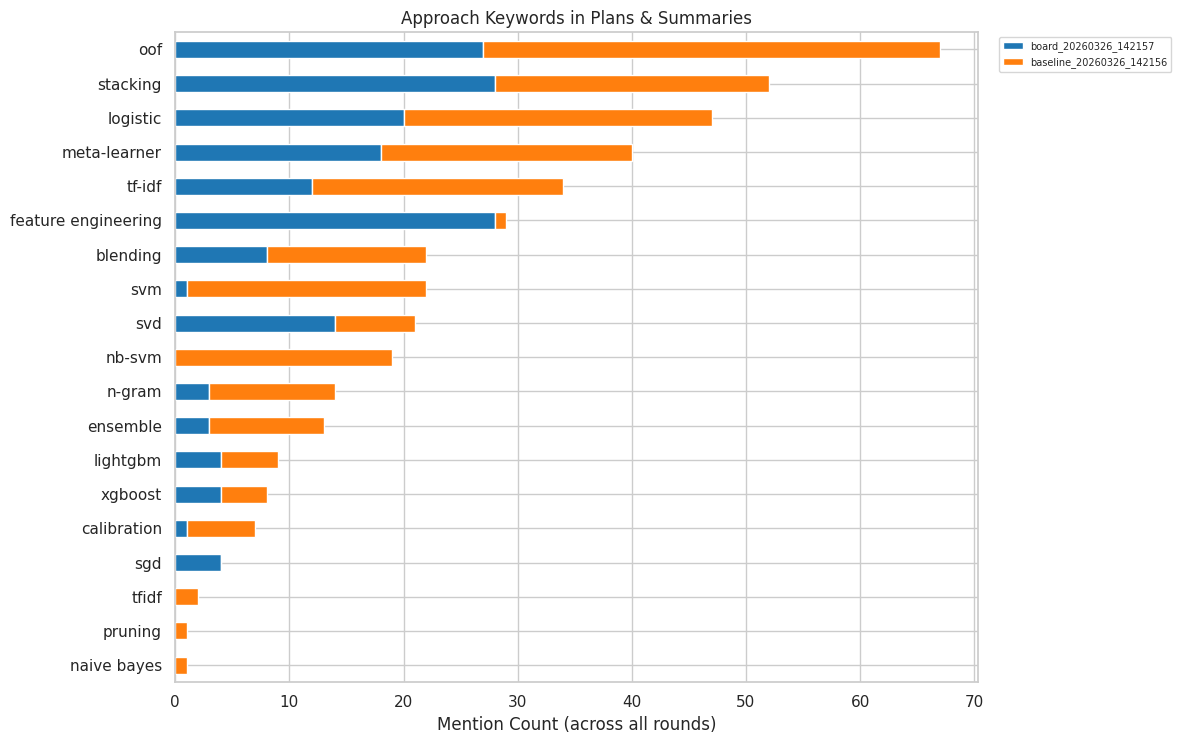

In [29]:
keywords = [
    "tfidf", "tf-idf", "logistic", "svm", "nb-svm", "naive bayes",
    "stacking", "ensemble", "blending", "calibration", "glove", "embedding",
    "xgboost", "lightgbm", "random forest", "sgd", "svd",
    "feature engineering", "n-gram", "meta-learner",
    "oof", "temperature scaling", "pruning"
]

kw_data = {}
for r in runs:
    counts = defaultdict(int)
    for rd in r["log"]:
        text = (rd.get("coding_summary", "") + " " + rd.get("plan", "")).lower()
        for kw in keywords:
            if kw in text:
                counts[kw] += 1
    kw_data[r["label"]] = dict(counts)

df_kw = pd.DataFrame(kw_data).fillna(0).astype(int)
df_kw = df_kw.loc[df_kw.sum(axis=1) > 0]
df_kw = df_kw.loc[df_kw.sum(axis=1).sort_values(ascending=True).index]  # sort ascending for barh

if not df_kw.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(df_kw))))
    df_kw.plot(kind="barh", ax=ax, stacked=True, color=[r["color"] for r in runs if r["label"] in df_kw.columns])
    ax.set_xlabel("Mention Count (across all rounds)")
    ax.set_title("Approach Keywords in Plans & Summaries")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword matches found.")

## 8. Summary Table

In [30]:
rows = []
for r in runs:
    scores = get_scores(r)
    cum_best = np.array([
        (np.nanmin(scores[:j+1]) if LOWER_IS_BETTER else np.nanmax(scores[:j+1]))
        for j in range(len(scores))
    ])
    valid_mask = ~np.isnan(scores)
    best_idx = int(np.nanargmin(scores)) if LOWER_IS_BETTER else int(np.nanargmax(scores))
    costs = [rd.get("estimated_cost_usd", 0) for rd in r["log"]]
    total_cost = sum(c for c in costs if c is not None)

    rows.append({
        "Run": r["label"],
        "Competition": r["competition"],
        "Strategy": r["strategy_tag"],
        "Rounds": len(r["log"]),
        "R1 Score": scores[0] if not np.isnan(scores[0]) else None,
        "Best Score": cum_best[-1] if not np.isnan(cum_best[-1]) else None,
        "Best @ Round": r["log"][best_idx]["round"] if valid_mask.any() else "-",
        "Improvement": abs(scores[0] - cum_best[-1]) if not np.isnan(scores[0]) and not np.isnan(cum_best[-1]) else None,
        "Total Cost ($)": f"${total_cost:.2f}" if total_cost > 0 else "-",
        "Cost/Round ($)": f"${total_cost/len(r['log']):.2f}" if total_cost > 0 else "-",
    })

df_summary = pd.DataFrame(rows)
highlight_col = "Best Score"
if LOWER_IS_BETTER:
    styled = df_summary.style.highlight_min(subset=[highlight_col], color="#c6efce")
else:
    styled = df_summary.style.highlight_max(subset=[highlight_col], color="#c6efce")
styled

,Run,Competition,Strategy,Rounds,R1 Score,Best Score,Best @ Round,Improvement,Total Cost ($),Cost/Round ($)
0,board_20260326_142157,random-acts-of-pizza,board,28,0.651650,0.674720,3,0.023070,$24.33,$0.87
1,baseline_20260326_142156,random-acts-of-pizza,baseline,40,0.685310,0.694960,18,0.009650,$12.33,$0.31
